1. Cadrage et besoin client

La SAE 2.04 porte sur l’exploitation d’une base de données de capteurs dans un environnement industriel. L’entreprise étudiée est une usine produisant des rouleaux de papier à l’aide d’une machine industrielle équipée de nombreux capteurs répartis sur la chaîne de fabrication.

Ces capteurs permettent de suivre différents paramètres importants pour la qualité de production, comme la température, l’humidité ou d’autres mesures techniques. Cependant, ils peuvent se dérégler avec le temps ou tomber en panne, ce qui peut entraîner des mesures incorrectes et nuire au contrôle de la qualité.

Le besoin du client est donc de vérifier si les capteurs fonctionnent correctement. Pour cela, il faut comparer les mesures automatiques enregistrées par les capteurs avec les mesures manuelles réalisées par les techniciens, détecter les écarts anormaux, produire des visualisations compréhensibles et proposer une amélioration de la base de données pour mieux suivre la fiabilité des capteurs.

Objectifs

Les objectifs fonctionnels de la SAE sont les suivants :

    -générer une carte de contrôle pour un capteur choisi ;

    -analyser les écarts entre mesures automatiques et manuelles ;

    -produire un histogramme et des indicateurs statistiques comme la moyenne et l’écart-type ;

    -implémenter des règles de détection d’anomalies avec p-valeurs ;

    -détecter une dérive éventuelle par régression linéaire ;

    -proposer une extension de la base de données pour suivre la fiabilité des capteurs.

2.Choix du capteur et périmètre du projet
Dans cette SAE, un capteur ou un jeu de données sera choisi dans la base de données fournie afin d’effectuer une analyse statistique complète. Le capteur retenu doit permettre de comparer une mesure automatique avec une mesure manuelle, de calculer l’écart entre les deux et d’étudier la fiabilité des mesures.

Le projet se limite à l’exploitation des données, à leur traitement dans SQL et Python, à la création de cartes de contrôle, d’histogrammes et de tests de détection, ainsi qu’à la conception d’une extension de la base de données pour suivre la fiabilité des capteurs. Les actions de maintenance, d’installation ou de développement d’interface ne font pas partie du périmètre.


Nombre de points : 28
mu   = -0.003744319871616289
sigma= 0.4127852186522945


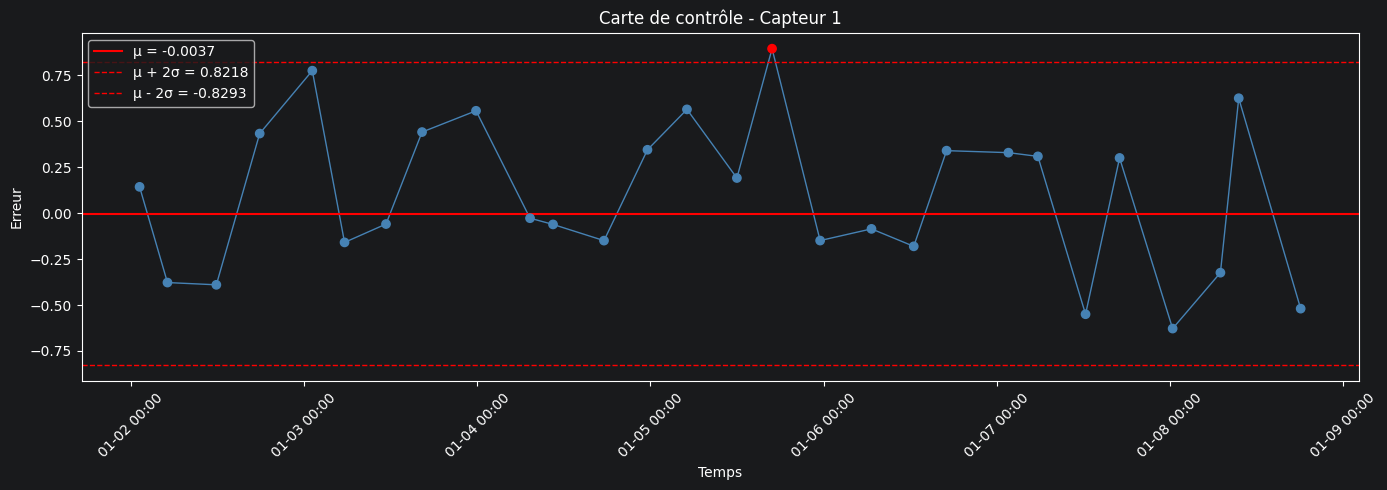

In [1]:
import psycopg
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# 1) Connexion à la base

conn = psycopg.connect(
    host="localhost",
    dbname="postgres",
    user="postgres",
    password="admin"
)


# 2) Récupérer les erreurs (fenêtre 8 jours)


SENSOR_ID = 1

query_points = """
    WITH errors AS (
        SELECT
            cm.controltimestamp,
            cm.controlvalue - sm.sensorvalue AS error
        FROM controlmeasurement cm
        JOIN sensormeasurement sm
            ON sm.sensorid = cm.sensorid
           AND sm.timestamp = cm.sensortimestamp
        WHERE cm.sensorid = %s
    )
    SELECT controltimestamp, error
    FROM errors
    WHERE controltimestamp BETWEEN '2023-01-02' AND '2023-01-09'
    ORDER BY controltimestamp;
"""

with conn.cursor() as cur:
    cur.execute(query_points, (SENSOR_ID,))
    rows = cur.fetchall()

timestamps = [r[0] for r in rows]
errors = [r[1] for r in rows]
print("Nombre de points :", len(errors))


# 2a) Calculer µ et σ sur TOUTES les erreurs du capteur 1


query_stats = """
    WITH errors AS (
        SELECT
            cm.controltimestamp,
            cm.controlvalue - sm.sensorvalue AS error
        FROM controlmeasurement cm
        JOIN sensormeasurement sm
            ON sm.sensorid = cm.sensorid
           AND sm.timestamp = cm.sensortimestamp
        WHERE cm.sensorid = %s
    )
    SELECT
        AVG(error)    AS mu,
        STDDEV(error) AS sigma
    FROM errors;
"""

with conn.cursor() as cur:
    cur.execute(query_stats, (SENSOR_ID,))
    mu, sigma = cur.fetchone()

print("mu   =", mu)
print("sigma=", sigma)


# 3) Tracer la carte de contrôle
fig, ax = plt.subplots(figsize=(14, 5))

colors = [
    "red" if (e < mu - 2*sigma or e > mu + 2*sigma) else "steelblue"
    for e in errors
]

ax.plot(timestamps, errors, color="steelblue", linewidth=1)
ax.scatter(timestamps, errors, color=colors, zorder=5)

ax.axhline(mu,color="red", linestyle="-",  linewidth=1.5, label=f"µ = {mu:.4f}")
ax.axhline(mu + 2*sigma, color="red",   linestyle="--", linewidth=1,   label=f"µ + 2σ = {mu+2*sigma:.4f}")
ax.axhline(mu - 2*sigma, color="red",   linestyle="--", linewidth=1,   label=f"µ - 2σ = {mu-2*sigma:.4f}")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.xticks(rotation=45)

ax.set_title(f"Carte de contrôle - Capteur {SENSOR_ID}")
ax.set_xlabel("Temps")
ax.set_ylabel("Erreur")
ax.legend()
plt.tight_layout()
plt.show()



In [3]:
import numpy as np
#2.1  Dans cette partie, on calcule l’ensemble des erreurs du capteur choisi (différence entre la mesure manuelle de référence et la mesure automatique), afin d’analyser statistiquement leur répartition et de vérifier qu’elles suivent à peu près une loi normale. Ces résultats serviront ensuite de base aux exercices suivants
query_all_errors = """
    WITH errors AS (
        SELECT
            cm.controltimestamp,
            cm.controlvalue - sm.sensorvalue AS error
        FROM controlmeasurement cm
        JOIN sensormeasurement sm
            ON sm.sensorid = cm.sensorid
           AND sm.timestamp = cm.sensortimestamp
        WHERE cm.sensorid = %s
    )
    SELECT error
    FROM errors;
"""

with conn.cursor() as cur:
    cur.execute(query_all_errors, (SENSOR_ID,))
    rows_all = cur.fetchall()

errors_all = np.array([r[0] for r in rows_all], dtype=float)
print("Total number of errors:", len(errors_all))

Total number of errors: 2005


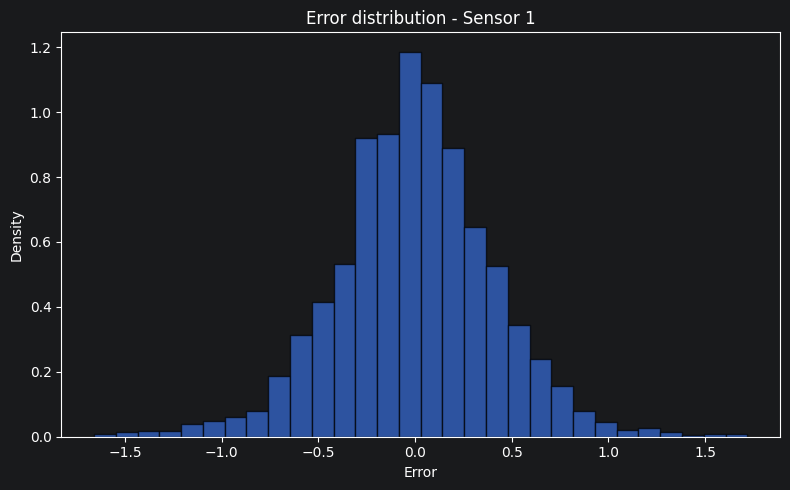

In [4]:
#2.1 On trace ensuite l’histogramme des erreurs pour vérifier que leur répartition est proche d’une loi normale centrée
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(errors_all, bins=30, density=True, edgecolor="black", alpha=0.7)

ax.set_title(f"Error distribution - Sensor {SENSOR_ID}")
ax.set_xlabel("Error")
ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

In [5]:
# exo 1,2,3 au mm temps →Proportion de mesures dans l’intervalle [µ − σ, µ + σ] , [µ − 2σ, µ + 2σ],[µ − 3σ, µ + 3σ]
N = len(errors_all)

# Intervals around mu
intervals = [
    ("±1σ", 1), #On obtient 71.22 % des erreurs dans l’intervalle [µ − σ, µ + σ], ce qui est proche de la valeur théorique 68% attendue pour une loi normale.
    ("±2σ", 2), #94.91% au lieu de 95% → quasiment parfait.
    ("±3σ", 3),# 98.95% au lieu de 99.7% → un peu moins, mais raisonnable.
]

for label, k in intervals:
    lower = mu - k * sigma
    upper = mu + k * sigma
    count = np.sum((errors_all >= lower) & (errors_all <= upper))
    percent = 100 * count / N
    print(f"{label}: {count} points, {percent:.2f}% of all errors")

±1σ: 1428 points, 71.22% of all errors
±2σ: 1903 points, 94.91% of all errors
±3σ: 1984 points, 98.95% of all errors


In [6]:
#exo 4 →Proportion de mesures en dehors des intervalles [µ ± σ], [µ ± 2σ] et [µ ± 3σ]
# on obtient 28.78% des erreurs en dehors de l'intervalle[µ − σ, µ + σ]
# on obtient 5.09% des erreurs en dehors de l'intervalle[µ − 2σ, µ + 2σ]
# on obtient 1.05% des erreurs en dehors de l'intervalle [µ − 3σ, µ + 3σ]
for label, k in intervals:
    lower = mu - k * sigma
    upper = mu + k * sigma
    inside = np.sum((errors_all >= lower) & (errors_all <= upper))
    outside = N - inside
    percent_outside = 100 * outside / N
    print(f"Outside {label}: {outside} points, {percent_outside:.2f}% of all errors")

Outside ±1σ: 577 points, 28.78% of all errors
Outside ±2σ: 102 points, 5.09% of all errors
Outside ±3σ: 21 points, 1.05% of all errors


In [7]:
# 2.2 – p-valeur et règles de détection
# Dans cette partie, nous définissons plusieurs règles automatiques de détection sur la carte de contrôle
# (par exemple :  au moins 8 points sur les 10 derniers sont du même côté de la moyenne )
# Pour chaque règle, nous calculons sa p-valeur théorique en supposant que les erreurs du capteur
# suivent une loi normale centrée
# Ensuite nous implémentons la règle en Python/SQL et vérifions si elle se déclenche sur notre carte de contrôle.

#1a)Règle 1 : au moins 8 points sur les 10 derniers du même côté de la moyenne
#Cette p‑valeur doit être < 0,05 pour que la règle soit “raisonnablement stricte” (peu de faux positifs)
from math import comb


import numpy as np
from math import comb

def binom_p_ge_k(n, p, k):
    return sum(comb(n, i) * (p**i) * ((1-p)**(n-i)) for i in range(k, n+1))
p_one_side = binom_p_ge_k(n=10, p=0.5, k=8)
p_rule = 2 * p_one_side

print("p_one_side (X >= 8 above mean) =", p_one_side)
print("p-value for rule '8 out of 10 on the same side' =", p_rule)

#1b)Implémentation de la règle sur mes données
last_10 = np.array(errors_all[-10:])

above_mean = last_10 > mu
below_mean = last_10 < mu

count_above = np.sum(above_mean)
count_below = np.sum(below_mean)

rule_triggered = (count_above >= 8) or (count_below >= 8)

print("Last 10 errors:", last_10)
print("Number above mean:", count_above)
print("Number below mean:", count_below)

if rule_triggered:
    print("RÈGLE 1 DÉCLENCHÉE : au moins 8 des 10 derniers points sont du même côté de la moyenne.")
else:
    print("RÈGLE 1 NON DÉCLENCHÉE")



#2a)
# p-valeur pour la règle :
# au moins 2 des 7 derniers points sont en dehors de l'intervalle [mu - 2*sigma, mu + 2*sigma]

def binom_p_ge_k(n, p, k):
    return sum(comb(n, i) * (p**i) * ((1-p)**(n-i)) for i in range(k, n+1))

p_two_or_more_outliers = binom_p_ge_k(n=7, p=0.05, k=2)

print("p-value for rule 'at least 2 out of 7 outside ±2σ' =", p_two_or_more_outliers)

#2b)
# Implémentation de la règle sur les 7 dernières erreurs

last_7 = np.array(errors_all[-7:])

outside_2sigma = (last_7 < mu - 2*sigma) | (last_7 > mu + 2*sigma)
count_outside_2sigma = np.sum(outside_2sigma)

print("Last 7 errors:", last_7)
print("Number of points outside [mu - 2*sigma, mu + 2*sigma]:", count_outside_2sigma)

if count_outside_2sigma >= 2:
    print("RÈGLE 2 DÉCLENCHÉE : au moins 2 des 7 derniers points sont en dehors de ±2σ")
else:
    print("RÈGLE 2 NON DÉCLENCHÉE.")




#3a)
# au moins 7 des 10 derniers points sont en dehors de l'intervalle [mu - sigma, mu + sigma]

p_outside_1sigma_theoretical = 1 - 0.68

p_7_or_more_outside = binom_p_ge_k(n=10, p=p_outside_1sigma_theoretical, k=7)

print("p-value for rule 'at least 7 out of 10 outside ±1σ' =", p_7_or_more_outside)


#3b)
# Implémentation de la règle sur les 10 dernières erreurs
last_10 = np.array(errors_all[-10:])

outside_1sigma = (last_10 < mu - sigma) | (last_10 > mu + sigma)
count_outside_1sigma = np.sum(outside_1sigma)

print("Last 10 errors:", last_10)
print("Number of points outside [mu - sigma, mu + sigma]:", count_outside_1sigma)

if count_outside_1sigma >= 7:
    print("RÈGLE 3 DÉCLENCHÉE : au moins 7 des 10 derniers points sont en dehors de ±1σ")
else:
    print("RÈGLE 3 NON DÉCLENCHÉE.")






#4) Règle de détection de défaillance d'origine (valeur p entre 0,01 et 0,05)
# au moins 5 des 8 derniers points sont supérieurs à mu + sigma"
#si la valeur affichée est bien entre 0.01 et 0.05 on est parfaitement dans la zone demandée.
from math import comb
n = 8
# Probabilité théorique qu'un point soit au-dessus de mu + sigma ≈ 0,16
p_above_mu_plus_sigma = 0.16
k = 5

p_ge_5 = 0.0
for i in range(k, n + 1):
    p_ge_5 += comb(n, i) * (p_above_mu_plus_sigma ** i) * ((1 - p_above_mu_plus_sigma) ** (n - i))

p_value_rule4 = p_ge_5
print("2.2.4 – Theoretical p-value (rule 4) =", p_value_rule4)





# Implémentation de la règle originale sur les 8 dernières erreurs
#Vérification : au moins 5 des 8 dernières erreurs sont au-dessus de mu + sigma
import numpy as np

#  Application de la règle aux 8 dernières erreurs

last_8 = np.array(errors_all[-8:])

above_mu_plus_sigma = last_8 > (mu + sigma)
count_above_mu_plus_sigma = np.sum(above_mu_plus_sigma)

print("Last 8 errors:", last_8)
print("Points above mu + sigma:", count_above_mu_plus_sigma)

if count_above_mu_plus_sigma >= 5:
    print("RÈGLE 4 DÉCLENCHÉE : au moins 5 des 8 derniers points sont au-dessus de mu + sigma.")
else:
    print("RÈGLE 4 NON DÉCLENCHÉE.")




p_one_side (X >= 8 above mean) = 0.0546875
p-value for rule '8 out of 10 on the same side' = 0.109375
Last 10 errors: [ 0.05745488 -0.17973379  0.73324786  0.06863306  0.22441359 -0.22337364
 -0.3242234  -0.06734548  0.00611192  0.13896399]
Number above mean: 6
Number below mean: 4
RÈGLE 1 NON DÉCLENCHÉE
p-value for rule 'at least 2 out of 7 outside ±2σ' = 0.0443805421875
Last 7 errors: [ 0.06863306  0.22441359 -0.22337364 -0.3242234  -0.06734548  0.00611192
  0.13896399]
Number of points outside [mu - 2*sigma, mu + 2*sigma]: 0
RÈGLE 2 NON DÉCLENCHÉE.
p-value for rule 'at least 7 out of 10 outside ±1σ' = 0.01550293802978114
Last 10 errors: [ 0.05745488 -0.17973379  0.73324786  0.06863306  0.22441359 -0.22337364
 -0.3242234  -0.06734548  0.00611192  0.13896399]
Number of points outside [mu - sigma, mu + sigma]: 1
RÈGLE 3 NON DÉCLENCHÉE.
2.2.4 – Theoretical p-value (rule 4) = 0.0038303055216639998
Last 8 errors: [ 0.73324786  0.06863306  0.22441359 -0.22337364 -0.3242234  -0.06734548
  0

In [ ]:
#2.3) Dérive et régression

# 1) Régression linéaire sur les 10 derniers points pour la règle
last_10 = np.array(errors_all[-10:])
t = np.arange(1, 11)
slope_rule, intercept_rule = np.polyfit(t, last_10, 1)

print("Slope (coefficient directeur) =", slope_rule)
print("Intercept =", intercept_rule)


# 2) Règle basée sur la pente
threshold_slope = 0.05

if abs(slope_rule) > threshold_slope:
    print("RÈGLE RÉGRESSION DÉCLENCHÉE : dérive détectée (pente trop forte).")
else:
    print("RÈGLE RÉGRESSION NON DÉCLENCHÉE : pas de dérive significative.")

# 3) Estimation expérimentale de la p‑valeur

rng = np.random.default_rng(0)

mu_sim = 0.0
sigma_sim = 1.0
n_points = 10
n_simulations = 10000

count_triggered = 0

for _ in range(n_simulations):
    sample = rng.normal(loc=mu_sim, scale=sigma_sim, size=n_points)
    t_sim = np.arange(1, n_points + 1)
    a_sim, b_sim = np.polyfit(t_sim, sample, 1)
    if abs(a_sim) > threshold_slope:
        count_triggered += 1

p_value_slope = count_triggered / n_simulations
print("2.3 – p-valeur expérimentale de la règle sur la pente ≈", p_value_slope)

# 4) CARTE DE CONTRÔLE AVEC DROITE DE RÉGRESSION

fig, ax = plt.subplots(figsize=(14, 5))

colors = [
    "red" if (e < mu - 2*sigma or e > mu + 2*sigma) else "steelblue"
    for e in errors
]

ax.plot(timestamps, errors, color="steelblue", linewidth=1, label="Measurement error")
ax.scatter(timestamps, errors, color=colors, zorder=5)

ax.axhline(mu,            color="red", linestyle="-",  linewidth=1.5, label=f"µ = {mu:.4f}")
ax.axhline(mu + 2*sigma,  color="red", linestyle="--", linewidth=1,   label=f"µ + 2σ = {mu+2*sigma:.4f}")
ax.axhline(mu - 2*sigma,  color="red", linestyle="--", linewidth=1,   label=f"µ - 2σ = {mu-2*sigma:.4f}")

# Régression linéaire sur les 10 derniers points (affichage sur la carte)
last_10_times = np.array(timestamps[-10:])
last_10_errors = np.array(errors[-10:], dtype=float)

x_num = mdates.date2num(last_10_times)
slope, intercept = np.polyfit(x_num, last_10_errors, 1)
regression_line = slope * x_num + intercept

ax.plot(
    last_10_times,
    regression_line,
    color="orange",
    linewidth=2.5,
    label=f"10-point regression (slope = {slope:.4f})"
)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.xticks(rotation=45)

ax.set_title(f"Carte de contrôle avec régression - Capteur {SENSOR_ID}")
ax.set_xlabel("Temps")
ax.set_ylabel("Erreur")
ax.legend()
plt.tight_layout()
plt.show()